In [1]:
! pip install -r ../requirements.txt

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression


In [11]:
def load_dataset():
    import pandas as pd
    df = pd.read_csv("../BostonHousing.csv")
    return df
load_dataset()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


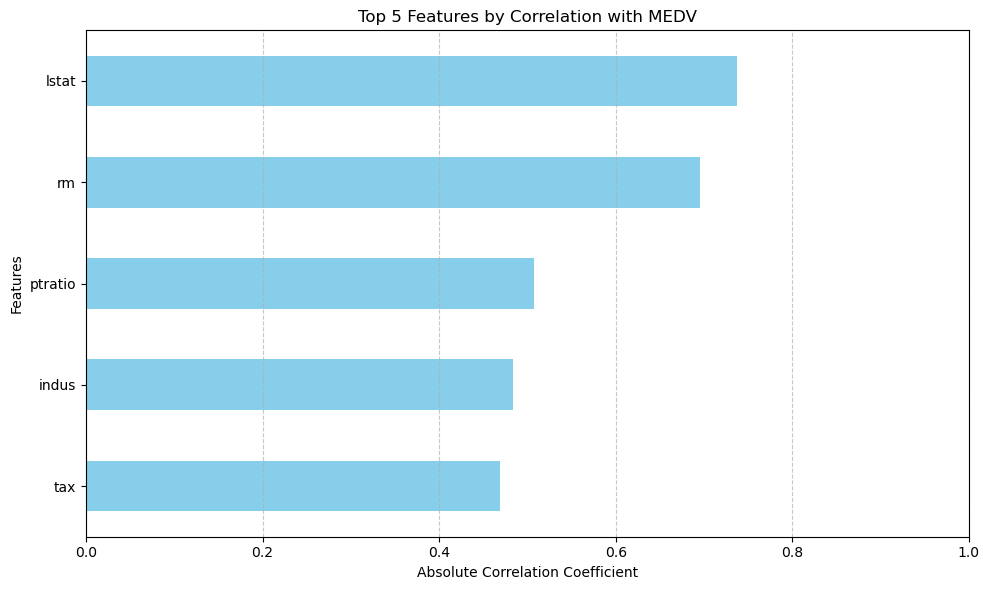

Top 5 features most correlated with home values:
         Correlation
lstat       0.737663
rm          0.695360
ptratio     0.507787
indus       0.483725
tax         0.468536


['lstat', 'rm', 'ptratio', 'indus', 'tax']

In [9]:

def select_features():
    method = 'correlation'
    k = 5
    df = load_dataset()
    X = df.drop(columns=['medv'])
    y = df['medv']

    # Calculate correlation with target
    corr_matrix = df.corr()
    corr_with_target = corr_matrix['medv'].abs().sort_values(ascending=False)
    corr_with_target = corr_with_target[1:]  # Remove 'medv' itself

    # Create and normalize scores
    feature_scores = pd.DataFrame({'Correlation': corr_with_target})
    feature_scores['Normalized'] = feature_scores['Correlation'] / feature_scores['Correlation'].max()

    # Select top k features
    top_features = feature_scores.nlargest(k, 'Correlation')
    
    # Visualization
    plt.figure(figsize=(10, 6))
    top_features['Correlation'].sort_values().plot(kind='barh', color='skyblue')
    plt.title(f'Top {k} Features by Correlation with MEDV')
    plt.xlabel('Absolute Correlation Coefficient')
    plt.ylabel('Features')
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Print results
    print(f"Top {k} features most correlated with home values:")
    print(top_features[['Correlation']])
    
    return top_features.index.tolist()
    top_features.index.tolist()

# Example usage:

select_features()


    

=== Model Evaluation ===
Training RMSE: 5.19
Test RMSE:     5.28
Training R²:   0.690
Test R²:       0.620


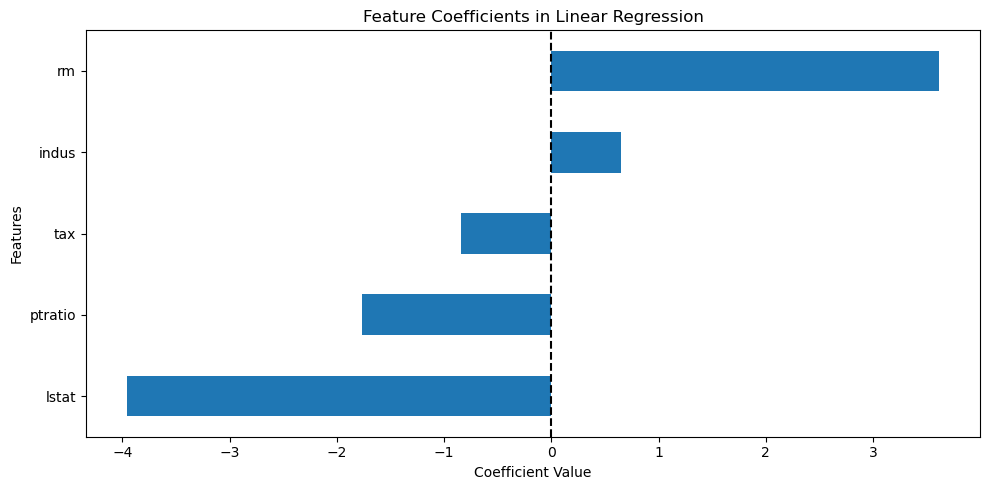

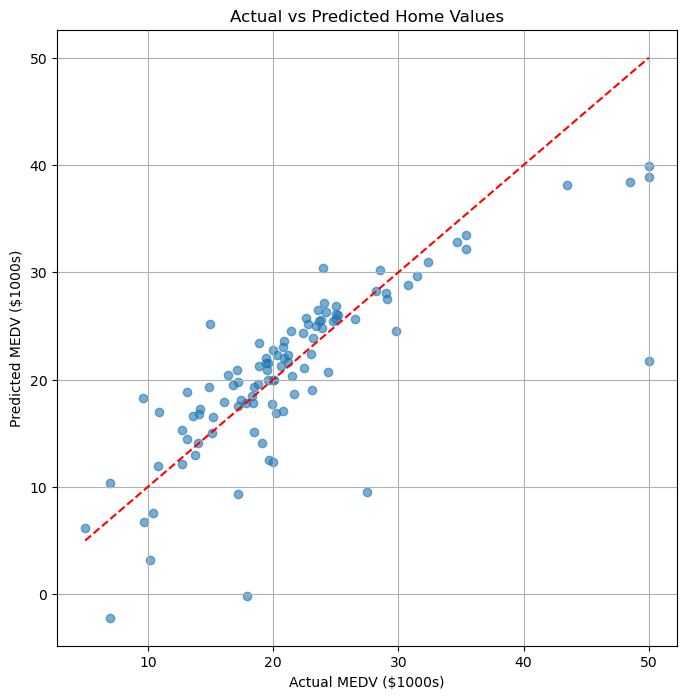

In [10]:
def train_linear_regression():
    # 1. Load and prepare data
    df = load_dataset()
    
    # 2. Feature selection (using top 5 correlated features)
    features = ['lstat', 'rm', 'ptratio', 'indus', 'tax']  # From correlation analysis
    X = df[features]
    y = df['medv']
    
    # 3. Train-test split (80-20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 4. Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 5. Train model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    
    # 6. Evaluate
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    # 7. Print results
    print("=== Model Evaluation ===")
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Test RMSE:     {test_rmse:.2f}")
    print(f"Training R²:   {train_r2:.3f}")
    print(f"Test R²:       {test_r2:.3f}")
    
    # 8. Plot coefficients
    plt.figure(figsize=(10, 5))
    coefficients = pd.Series(model.coef_, index=features).sort_values()
    coefficients.plot(kind='barh')
    plt.title('Feature Coefficients in Linear Regression')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.axvline(x=0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 9. Plot predictions vs actual
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, test_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title('Actual vs Predicted Home Values')
    plt.xlabel('Actual MEDV ($1000s)')
    plt.ylabel('Predicted MEDV ($1000s)')
    plt.grid(True)
    plt.show()
    
    return model, scaler

# Run the training
trained_model, feature_scaler = train_linear_regression()